In [1]:
import numpy as np
import pymc3 as pm
import arviz as az
import matplotlib.pyplot as plt

from dataclasses import dataclass
from colorsys import hls_to_rgb

np.random.seed(42)

# Bayesian Optimization

In [2]:
@dataclass
class HSL:
    """https://www.w3schools.com/colors/colors_hsl.asp"""
    hue: float  # 0-1
    saturation: float  # 0-1
    lightness: float = 0.5  # 0-1

    def dist(self, hsl):
        # https://en.wikipedia.org/wiki/Color_difference
        # https://docs.python.org/3/library/colorsys.html
        r1, g1, b1 = hls_to_rgb(self.hue, self.lightness, self.saturation)
        r2, g2, b2 = hls_to_rgb(hsl.hue, hsl.lightness, hsl.saturation)

        dr, dg, db = r1 - r2, g1 - g2, b1 - b2
        distance = np.sqrt(dr * dr + dg * dg + db * db)
        return distance


class Env:
    hue_len = 50
    sat_len = 50
    hue_domain = np.linspace(0, 1, hue_len)
    sat_domain = np.linspace(0, 1, sat_len)
    X, Y = np.meshgrid(hue_domain, sat_domain)
    _x = X.flatten()
    _y = Y.flatten()
    xy = np.vstack((_x, _y)).T


class User:
    def __init__(self, preference=HSL(335/360, 62/100)):
        self.preference = preference

    def response(self, hsl: HSL):
        dist = self.preference.dist(hsl)
        return Response(hsl, dist)


@dataclass()
class Response:
    hsl: HSL
    reward: float


class StateRepository:
    def __init__(self, responses=[]):
        self.responses = responses

    @property
    def X(self):
        hsls = [res.hsl for res in self.responses]
        X = np.array([(hsl.hue, hsl.saturation) for hsl in hsls])
        return X.T

    @property
    def y(self):
        rewards = [res.reward for res in self.responses]
        y = np.array(rewards)
        return y

    def append(self, response):
        self.responses.append(response)


class GPThompsonAgent:
    def __init__(self):
        self.model = None
        self.trace = None
        self.gp = None

    def get_param(self, X, y):
        self.model = pm.Model()
        with self.model:
            length = pm.Gamma('length', 2, 0.5)
            cov = pm.gp.cov.ExpQuad(input_dim=2, ls=length) + pm.gp.cov.WhiteNoise(1E-5)
            self.gp = pm.gp.Marginal(cov_func=cov)
            eps = pm.HalfNormal('eps', 20)
            y_pred = self.gp.marginal_likelihood('y_pred', X=X.T, y=y, noise=eps)
            self.trace = pm.sample(1000, chains=1)

        with self.model:
            f_pred = self.gp.conditional('f_pred', Env.xy)
            pred_samples = pm.sample_posterior_predictive(self.trace, var_names=["f_pred"], samples=1)

        Z_ = pred_samples['f_pred'][0].reshape((Env.hue_len, Env.sat_len))
        ind = np.unravel_index(np.argmax(Z_, axis=None), Z_.shape)
        hue = Env.hue_domain[ind[0]]
        sat = Env.sat_domain[ind[1]]
        return HSL(hue, sat)

In [3]:
env = Env()
user = User()
agent = GPThompsonAgent()

In [4]:
res1 = user.response(HSL(0, 0))
res2 = user.response(HSL(0, 0.5))
res3 = user.response(HSL(0.2, 0))
res4 = user.response(HSL(0.5, 0.5))

repo = StateRepository([res1, res2, res3, res4])

In [5]:
# Bayes opt
N = 10
for i in range(N):
    hsl = agent.get_param(repo.X, repo.y)
    response = user.response(hsl)
    repo.append(response)

/var/folders/4_/vrr8kzqn5b9dxsprxn13022m0000gn/T/ipykernel_60448/2993377780.py:79: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  self.trace = pm.sample(1000, chains=2)
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 4 jobs)
NUTS: [eps, length]


/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 11 seconds.
There were 4 divergences after tuning. Increase `target_accept` or reparameterize.
There were 5 divergences after tuning. Increase `target_accept` or reparameterize.
/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/pymc3/sampling.py:1689: UserWarning: samples parameter is smaller than nchains times ndraws, some draws and/or chains may not be represented in the returned posterior predictive sample
  warnings.warn(


/var/folders/4_/vrr8kzqn5b9dxsprxn13022m0000gn/T/ipykernel_60448/2993377780.py:79: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  self.trace = pm.sample(1000, chains=2)
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 4 jobs)
NUTS: [eps, length]


/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 9 seconds.
There were 2 divergences after tuning. Increase `target_accept` or reparameterize.
/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/pymc3/sampling.py:1689: UserWarning: samples parameter is smaller than nchains times ndraws, some draws and/or chains may not be represented in the returned posterior predictive sample
  warnings.warn(


/var/folders/4_/vrr8kzqn5b9dxsprxn13022m0000gn/T/ipykernel_60448/2993377780.py:79: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  self.trace = pm.sample(1000, chains=2)
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 4 jobs)
NUTS: [eps, length]


...

/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 11 seconds.
/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/pymc3/sampling.py:1689: UserWarning: samples parameter is smaller than nchains times ndraws, some draws and/or chains may not be represented in the returned posterior predictive sample
  warnings.warn(


/var/folders/4_/vrr8kzqn5b9dxsprxn13022m0000gn/T/ipykernel_60448/2993377780.py:79: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  self.trace = pm.sample(1000, chains=2)
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 4 jobs)
NUTS: [eps, length]


/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 12 seconds.
/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/pymc3/sampling.py:1689: UserWarning: samples parameter is smaller than nchains times ndraws, some draws and/or chains may not be represented in the returned posterior predictive sample
  warnings.warn(


/var/folders/4_/vrr8kzqn5b9dxsprxn13022m0000gn/T/ipykernel_60448/2993377780.py:79: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  self.trace = pm.sample(1000, chains=2)
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 4 jobs)
NUTS: [eps, length]


/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 11 seconds.
/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/pymc3/sampling.py:1689: UserWarning: samples parameter is smaller than nchains times ndraws, some draws and/or chains may not be represented in the returned posterior predictive sample
  warnings.warn(


<Figure size 432x288 with 0 Axes>

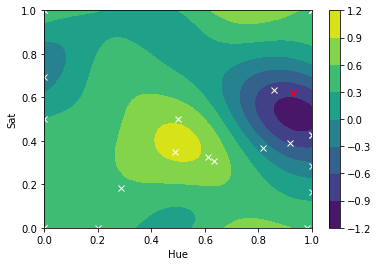

In [6]:
with agent.model:
    _f = agent.gp.conditional('_f', Env.xy)
    pred_samples = pm.sample_posterior_predictive(agent.trace, var_names=["_f"], samples=1)
    Z_ = pred_samples['_f'][0].reshape((Env.hue_len, Env.sat_len))

fig = plt.figure()
fig, ax = plt.subplots(1, 1)

cp = ax.contourf(Env.hue_domain, Env.sat_domain, Z_.T)

ax.plot(user.preference.hue, user.preference.saturation, 'rx')

res_hues = [res.hsl.hue for res in repo.responses]
res_sats = [res.hsl.saturation for res in repo.responses]
ax.plot(res_hues, res_sats, 'xw')

fig.colorbar(cp)
ax.set_xlabel('Hue')
ax.set_ylabel('Sat')
plt.show()